QUESTIONS/IDEAS:

- TODO: How to get the resolution between two adjacent reference points from the no. of reference points?
    - If the original times are in units of days, then 16 reference points, for example, mean there is 1/16 days between two adjacent points.
- TODO: How to visualize VAE latent representations? Should we only use the mean or the entire mean + epsilon * sigma?
    - See this page: https://avandekleut.github.io/vae/ -- we should use mean + epsilon * sigma and use num_sample=1 in the code.
- We should use the decoder part of the trained model and interpolate light curves and see the interpolation performance. Perhaps that may give some hints about how is the performance and even point out to some bugs in my implementation.
- What value of `num_sample` to use in mTAN? Default is 10. [This line](https://github.com/reml-lab/mTAN/blob/7a3d536ee742f1cacb4a6d3478ac78a228d995ff/src/tan_interpolation.py#L97) and below use multiple values of `num_sample`'s.
- Distribution of seq_len plot. max_seq_len must not have significant outliers.
- Confirm again whether I have interpreted the no. of reference points correctly: hope it's the no. of points only and not the actual time.
- Some quick tests to ensure I have prepared the data well?
- For the cases we are manually adding using the full lcs from API, the ndethist condition may not be appropriate. Since these are full light curves, ndethist will be > 80 in non-trivial no. of cases. Instead, I think we should manually look at the light curves and select subregions ourselves, majorly around the event of interest.

**VAE**:
- https://savadikarc.github.io/post/2020/01/30/vae_vis/
- https://kvfrans.com/variational-autoencoders-explained/

**Papers using VAE**:
- https://academic.oup.com/g3journal/article/11/1/jkaa036/6105578

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('ticks')
sns.set_context('talk')  # change to 'paper' later.

In [2]:
# We collate come subclasses into a single class based on the below rule.
agn_list = ['AGN','Blazar','BLLac','LINER','QSO','Seyfert', 'Seyfert_1', 'Seyfert_2']
stars_list = ['EB*','CataclyV*','LMXB','RRLyr','RotV*','Star','WD*','low-mass*']
simbad_galaxies_list = [
        "galaxy",
        "Galaxy",
        "EmG",
        "Seyfert",
        "Seyfert_1",
        "Seyfert_2",
        "BlueCompG",
        "StarburstG",
        "LSB_G",
        "HII_G",
        "High_z_G",
        "GinPair",
        "GinGroup",
        "BClG",
        "GinCl",
        "PartofG",
        "Compact_Gr_G",
        "IG",
        "PairG",
        "GroupG",
        "ClG",
        "SuperClG",
        "Void",
    ]

In [3]:
test_outputs_condensed = np.load('test_outputs_condensed.npy')
total_objIds = np.load('total_objIds.npy')
total_objIds_encoded = np.load('total_objIds_encoded.npy')
total_common_finkclasses = np.load('total_common_finkclasses.npy', allow_pickle=True)
train_objIds = np.load('train_objIds.npy')
val_objIds = np.load('val_objIds.npy')
test_objIds = np.load('test_objIds.npy')
test_outputs_condensed.shape, total_objIds.shape, total_objIds_encoded.shape, total_common_finkclasses.shape, train_objIds.shape, val_objIds.shape, test_objIds.shape

((1620, 1, 16, 16), (5398,), (5398,), (5398, 2), (2644,), (1134,), (1620,))

In [4]:
test_finkclasses = []
for tobjId in test_objIds:
    idx = np.where(total_objIds == tobjId)[0][0]
    test_finkclasses.append(total_common_finkclasses[idx])

test_finkclasses = np.array(test_finkclasses)

In [5]:
len(test_finkclasses)

1620

Each row in `total_objIds` and `total_common_finkclasses` correspond to the same objectId.

In [6]:
from sklearn import preprocessing
le = preprocessing.LabelEncoder()
objIds_encoded = le.fit_transform(total_objIds)  # use le.inverse_transform to get the string from the encoded value.

/home/oem/.local/lib/python3.8/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


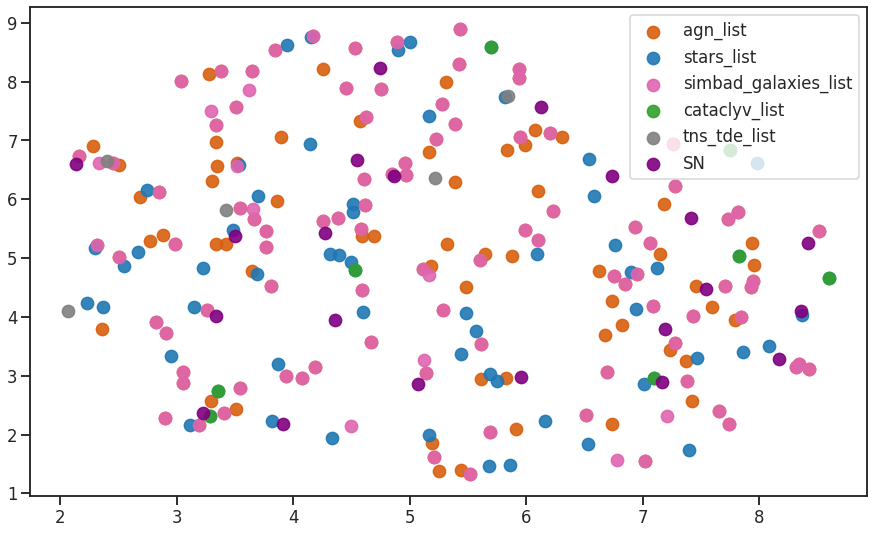

In [7]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from mpl_toolkits.axes_grid1 import make_axes_locatable
import umap
from sklearn.manifold import TSNE

test_outputs_condensed_condensed = test_outputs_condensed.mean(1).mean(2)
test_outputs_condensed_condensed = test_outputs_condensed_condensed[:, :6]  # Because most light curves have ~<10 datapoints. See the histogram below.
# test_outputs_condensed_condensed = test_outputs_condensed[:, 0, :, :].mean(2)

agn_indicator = np.apply_along_axis(lambda x: 1 if len([i for i in x if i in agn_list]) > 0 else 0, 1, test_finkclasses)
stars_indicator = np.apply_along_axis(lambda x: 1 if len([i for i in x if i in stars_list]) > 0 else 0, 1, test_finkclasses)
simbad_galaxies_indicator = np.apply_along_axis(lambda x: 1 if len([i for i in x if i in simbad_galaxies_list]) > 0 else 0, 1, test_finkclasses)
cataclyv_indicator = np.apply_along_axis(lambda x: 1 if len([i for i in x if i in ['CataclyV*']]) > 0 else 0, 1, test_finkclasses)
tns_tde_indicator = np.apply_along_axis(lambda x: 1 if len([i for i in x if i in ['TNS (TDE)']]) > 0 else 0, 1, test_finkclasses)
sn_indicator = np.apply_along_axis(lambda x: 1 if len([i for i in x if i in ['SN']]) > 0 else 0, 1, test_finkclasses)

colors = ['#d95f0e', '#1f78b4', '#df65b0', '#33a02c', 'gray', 'purple']

pca = False
umap_use = True
tsne = False

test_outputs_condensed_condensed_scaled = StandardScaler().fit_transform(test_outputs_condensed_condensed)

if pca:
    test_outputs_condensed_condensed_transformed = PCA(n_components=2).fit_transform(test_outputs_condensed_condensed_scaled)
elif umap_use:
    test_outputs_condensed_condensed_transformed = umap.UMAP(random_state=42).fit_transform(test_outputs_condensed_condensed_scaled)
elif tsne:
    test_outputs_condensed_condensed_transformed = TSNE(random_state=42).fit_transform(test_outputs_condensed_condensed_scaled)

fig, ax = plt.subplots(1, 1, figsize=(15, 9))
ax.scatter(
    test_outputs_condensed_condensed_transformed[:, 0][agn_indicator==1], test_outputs_condensed_condensed_transformed[:, 1][agn_indicator==1],
    c=colors[0], label='agn_list', s=150, alpha=0.9
)
ax.scatter(
    test_outputs_condensed_condensed_transformed[:, 0][stars_indicator==1], test_outputs_condensed_condensed_transformed[:, 1][stars_indicator==1],
    c=colors[1], label='stars_list', s=150, alpha=0.9
)
ax.scatter(
    test_outputs_condensed_condensed_transformed[:, 0][simbad_galaxies_indicator==1], test_outputs_condensed_condensed_transformed[:, 1][simbad_galaxies_indicator==1],
    c=colors[2], label='simbad_galaxies_list', s=150, alpha=0.9
)
ax.scatter(
    test_outputs_condensed_condensed_transformed[:, 0][cataclyv_indicator==1], test_outputs_condensed_condensed_transformed[:, 1][cataclyv_indicator==1],
    c=colors[3], label='cataclyv_list', s=150, alpha=0.9
)
ax.scatter(
    test_outputs_condensed_condensed_transformed[:, 0][tns_tde_indicator==1], test_outputs_condensed_condensed_transformed[:, 1][tns_tde_indicator==1],
    c=colors[4], label='tns_tde_list', s=150, alpha=0.9
)
ax.scatter(
    test_outputs_condensed_condensed_transformed[:, 0][sn_indicator==1], test_outputs_condensed_condensed_transformed[:, 1][sn_indicator==1],
    c=colors[5], label='SN', s=150, alpha=0.9
)
ax.legend()

Seems like AGNs and simbad_galaxies are close together?

In [8]:
# for oie in objIds_encoded:
#     objId = le.inverse_transform([oie])[0]
#     finkclass = objIds_finkclass_all[objIds_finkclass_all['objectId'] == objId]['finkclass'].tolist()
#     print(oie, objId, finkclass)

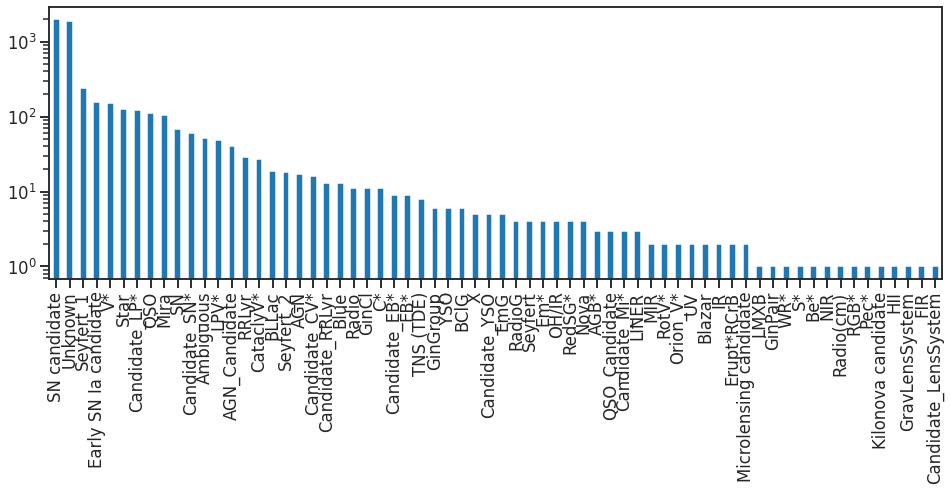

In [9]:
total_common_finkclasses_flatten = total_common_finkclasses.flatten()

fig, ax = plt.subplots(1, 1, figsize=(16, 5))
# NOTE: This does not include the ones we separately added to the alerts (TDEs)
pd.Series(
    total_common_finkclasses_flatten[total_common_finkclasses_flatten != '0'].flatten()  # !=0 because those were added just for apdding.
).value_counts().plot(kind='bar', ax=ax)
ax.set_yscale('log')

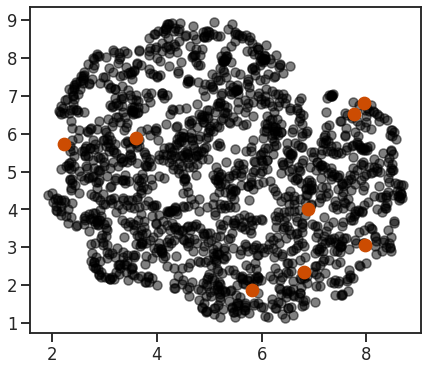

In [10]:
indicator = []
for i, oi in enumerate(total_objIds):
    if oi not in test_objIds:
        continue
    # fclasses = total_common_finkclasses[total_common_finkclasses['objectId'] == oi]['finkclass'].tolist()
    fclasses = total_common_finkclasses[i, :]
    if 'CataclyV*' in fclasses:
        indicator.append(1)
    else:
        indicator.append(0)

indicator = np.array(indicator)

fig, ax = plt.subplots(1, 1, figsize=(7, 6))
ax.scatter(
    test_outputs_condensed_condensed_transformed[:, 0][indicator == 0], test_outputs_condensed_condensed_transformed[:, 1][indicator == 0],
    c='black', alpha=0.5
)

ax.scatter(
    test_outputs_condensed_condensed_transformed[:, 0][indicator == 1], test_outputs_condensed_condensed_transformed[:, 1][indicator == 1],
    c='#cc4c02', s=150
)

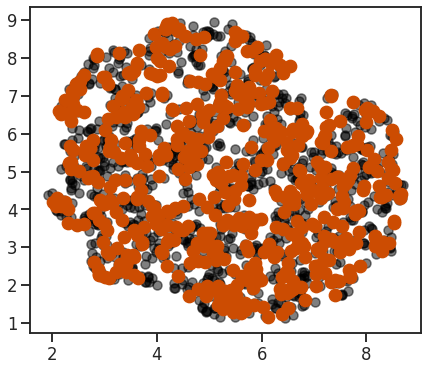

In [11]:
indicator = []
for i, oi in enumerate(total_objIds):
    if oi not in test_objIds:
        continue
    # fclasses = total_common_finkclasses[total_common_finkclasses['objectId'] == oi]['finkclass'].tolist()
    fclasses = total_common_finkclasses[i, :]
    if 'Unknown' in fclasses:
        indicator.append(1)
    else:
        indicator.append(0)

indicator = np.array(indicator)

fig, ax = plt.subplots(1, 1, figsize=(7, 6))
ax.scatter(
    test_outputs_condensed_condensed_transformed[:, 0][indicator == 0], test_outputs_condensed_condensed_transformed[:, 1][indicator == 0],
    c='black', alpha=0.5
)

ax.scatter(
    test_outputs_condensed_condensed_transformed[:, 0][indicator == 1], test_outputs_condensed_condensed_transformed[:, 1][indicator == 1],
    c='#cc4c02', s=150
)

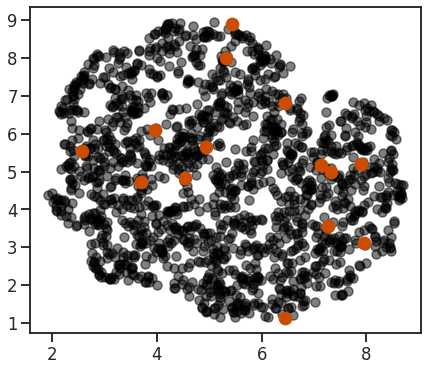

In [12]:
indicator = []
for i, oi in enumerate(total_objIds):
    if oi not in test_objIds:
        continue
    # fclasses = total_common_finkclasses[total_common_finkclasses['objectId'] == oi]['finkclass'].tolist()
    fclasses = total_common_finkclasses[i, :]
    if 'Ambiguous' in fclasses:
        indicator.append(1)
    else:
        indicator.append(0)

indicator = np.array(indicator)

fig, ax = plt.subplots(1, 1, figsize=(7, 6))
ax.scatter(
    test_outputs_condensed_condensed_transformed[:, 0][indicator == 0], test_outputs_condensed_condensed_transformed[:, 1][indicator == 0],
    c='black', alpha=0.5
)

ax.scatter(
    test_outputs_condensed_condensed_transformed[:, 0][indicator == 1], test_outputs_condensed_condensed_transformed[:, 1][indicator == 1],
    c='#cc4c02', s=150
)

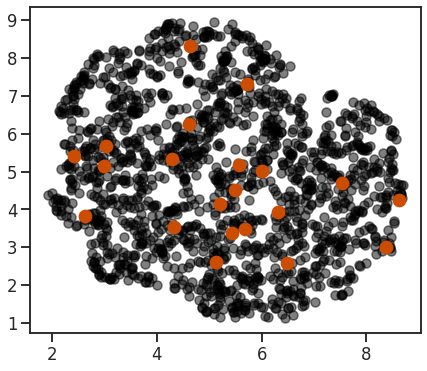

In [13]:
indicator = []
for i, oi in enumerate(total_objIds):
    if oi not in test_objIds:
        continue
    # fclasses = total_common_finkclasses[total_common_finkclasses['objectId'] == oi]['finkclass'].tolist()
    fclasses = total_common_finkclasses[i, :]
    if 'SN' in fclasses:
        indicator.append(1)
    else:
        indicator.append(0)

indicator = np.array(indicator)

fig, ax = plt.subplots(1, 1, figsize=(7, 6))
ax.scatter(
    test_outputs_condensed_condensed_transformed[:, 0][indicator == 0], test_outputs_condensed_condensed_transformed[:, 1][indicator == 0],
    c='black', alpha=0.5
)

ax.scatter(
    test_outputs_condensed_condensed_transformed[:, 0][indicator == 1], test_outputs_condensed_condensed_transformed[:, 1][indicator == 1],
    c='#cc4c02', s=150
)

## Checking for the cases added manually

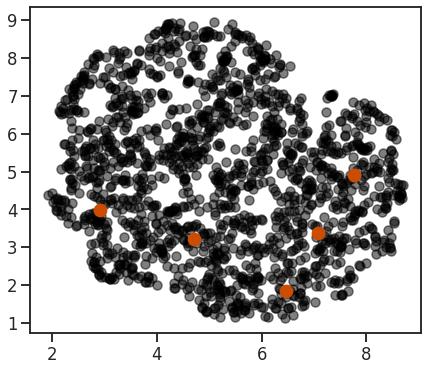

In [14]:
tns_tde_objId_list = ['ZTF24aaahxwr', 'ZTF24aaecooj', 'ZTF20aahmtso', 'ZTF22aafujzv', 'ZTF22aadesap', 'ZTF18aabdajx', 'ZTF21aanxhjv', 'ZTF22abegjtx']

indicator = []
for i, oi in enumerate(total_objIds):
    if oi not in test_objIds:
        continue
    # fclasses = total_common_finkclasses[total_common_finkclasses['objectId'] == oi]['finkclass'].tolist()
    fclasses = total_common_finkclasses[i, :]
    if oi in tns_tde_objId_list:
        indicator.append(1)
    else:
        indicator.append(0)

indicator = np.array(indicator)

fig, ax = plt.subplots(1, 1, figsize=(7, 6))
ax.scatter(
    test_outputs_condensed_condensed_transformed[:, 0][indicator == 0], test_outputs_condensed_condensed_transformed[:, 1][indicator == 0],
    c='black', alpha=0.5
)

ax.scatter(
    test_outputs_condensed_condensed_transformed[:, 0][indicator == 1], test_outputs_condensed_condensed_transformed[:, 1][indicator == 1],
    c='#cc4c02', s=150
)

## Looking at the light curves

In [15]:
df_alerts = pd.read_parquet('alerts_processed_ftransfer_ztf_2024_04_04_579178_copy.parquet')
df_alerts.shape

(43086, 20)

In [16]:
df_alerts.head(2)

,objectId,candid,magpsf,sigmapsf,fid,jd,ra,dec,tnsclass,cdsxmatch,roid,mulens,snn_snia_vs_nonia,snn_sn_vs_all,rf_snia_vs_nonia,rf_kn_vs_nonkn,tracklet,lc_features_g,lc_features_r,finkclass
0,ZTF19aayepga,1289250993415015013,17.345629,0.072883,2,2.459044e+06,245.981326,-23.702993,Unknown,AGB*,0,0.0,0.0,0.0,0.0,0.0,None,"{'amplitude': None, 'anderson_darling_normal':...","{'amplitude': 0.24104976654052734, 'anderson_d...",AGB*
1,ZTF18ablpige,1202501134115015017,18.025196,0.087649,2,2.458957e+06,279.295970,-8.802590,Unknown,AGB*,0,0.0,0.0,0.0,0.0,0.0,None,"{'amplitude': None, 'anderson_darling_normal':...","{'amplitude': 0.0, 'anderson_darling_normal': ...",AGB*


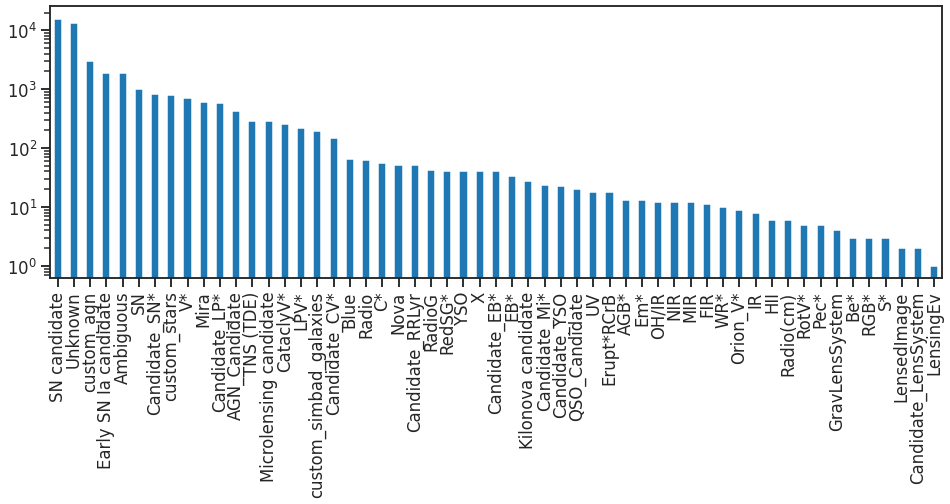

In [17]:
fig, ax = plt.subplots(1, 1, figsize=(16, 5))
df_alerts['finkclass'].value_counts().plot(kind='bar', ax=ax)
ax.set_yscale('log')

## Old analysis

Selecting points in the latent space manually and plotting their light curves to search for similarity

### Example 1

In [ ]:
two_close_z_indices = np.where(
    (outputs_condensed_condensed_transformed[:, 0] > 3) & (outputs_condensed_condensed_transformed[:, 1] > 1)
)[0]
two_close_z_objIds = objIds[two_close_z_indices]
two_close_z_objIds

array(['ZTF20abdajyr', 'ZTF20aauqwzc'], dtype='<U12')

In [ ]:
two_close_z_objId1 = objIds_finkclass_all[objIds_finkclass_all['objectId'] == two_close_z_objIds[0]]
two_close_z_objId1

,objectId,finkclass
350,ZTF20abdajyr,Early SN Ia candidate


In [ ]:
two_close_z_objId2 = objIds_finkclass_all[objIds_finkclass_all['objectId'] == two_close_z_objIds[1]]
two_close_z_objId2

,objectId,finkclass
959,ZTF20aauqwzc,SN candidate


In [20]:
def plot_lc(
        df_alerts, name, fid_column='fid', magpsf_column='magpsf', jd_column='jd',
        sigmapsf_column='sigmapsf', finkclass_column='finkclass', objectId_column='objectId'
):
    """Plots photometry for the given name (objectId) from the alerts dataframe.

    Parameters
    ----------
    name: str
        objectID
    """
    # Accumulate all alerts for the provided objectId
    pdf = df_alerts[df_alerts[objectId_column] == name].sort_values(by=jd_column)

    if pdf.empty:
        raise ValueError(f'No alerts exist for objectId = {name}!')

    fig = plt.figure(figsize=(15, 6))

    # Colors to plot
    colordic = {1: 'C0', 2: 'C1'}

    # Labels of ZTF filters
    filtdic = {1: 'g', 2: 'r'}

    for filt in np.unique(pdf[fid_column]):
        # select data from one filter at a time
        maskFilt = pdf[fid_column] == filt

        plt.errorbar(
            pdf[maskFilt][jd_column],
            pdf[maskFilt][magpsf_column],
            pdf[maskFilt][sigmapsf_column],
            ls = '', marker='o', color=colordic[filt], label=filtdic[filt]
        )

        plt.errorbar(
            pdf[maskFilt][jd_column],
            pdf[maskFilt][magpsf_column],
            pdf[maskFilt][sigmapsf_column],
            ls='', marker='^', color=colordic[filt]
        )

        if finkclass_column is not None:
            _offset_x = (pdf[maskFilt][jd_column].max() - pdf[maskFilt][jd_column].min()) / 200
            _offset_y = (pdf[maskFilt][magpsf_column].max() - pdf[maskFilt][magpsf_column].min()) / 100
            for x, y, string in zip(pdf[maskFilt][jd_column], pdf[maskFilt][magpsf_column], pdf[maskFilt][finkclass_column]):
                plt.text(
                    x+_offset_x, y+_offset_y, string,
                    color=colordic[filt]
                )

    plt.gca().invert_yaxis()
    plt.legend()
    plt.title(f'{pdf[objectId_column].unique()[0]}')
    plt.xlabel('Modified Julian Date')
    plt.ylabel('Magnitude')
    plt.show()
    # msg = """
    # - Circles (●) with error bars show valid alerts that pass the Fink quality cuts.
    # - Upper triangles with errors (▲), represent alert measurements that do not satisfy Fink quality cuts, but are nevetheless contained in the history of valid alerts and used by classifiers.
    # - Lower triangles (▽), represent 5-sigma mag limit in difference image based on PSF-fit photometry contained in the history of valid alerts.
    # """
    # print(msg)

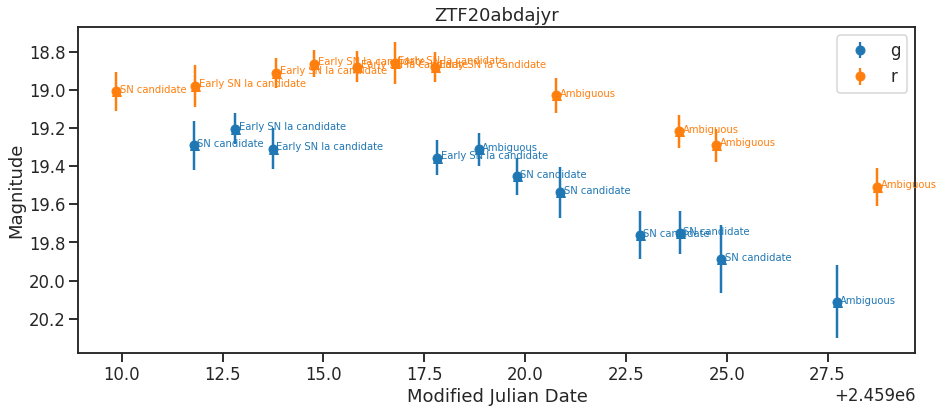

In [21]:
plot_lc(df_alerts, two_close_z_objId1['objectId'].iloc[0])

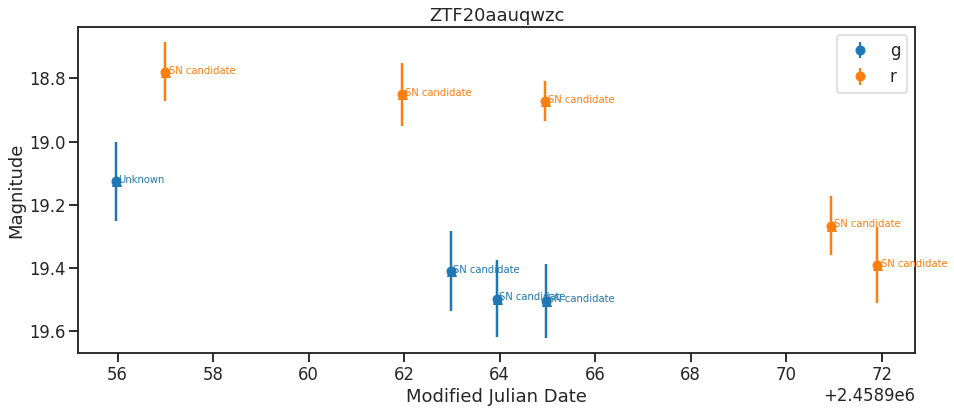

In [22]:
plot_lc(df_alerts, two_close_z_objId2['objectId'].iloc[0])

In [23]:
two_close_z_indices = np.where(
    (outputs_condensed_condensed_transformed[:, 0] < -2.5) & (outputs_condensed_condensed_transformed[:, 1] < -1.9)
)[0]
two_close_z_objIds = objIds[two_close_z_indices]
two_close_z_objIds

array(['ZTF20aavpyul', 'ZTF20aaacupl'], dtype='<U12')

In [24]:
two_close_z_objId1 = objIds_finkclass_all[objIds_finkclass_all['objectId'] == two_close_z_objIds[0]]
two_close_z_objId1

,objectId,finkclass
909,ZTF20aavpyul,SN candidate


In [25]:
two_close_z_objId2 = objIds_finkclass_all[objIds_finkclass_all['objectId'] == two_close_z_objIds[1]]
two_close_z_objId2

,objectId,finkclass
730,ZTF20aaacupl,RedSG*


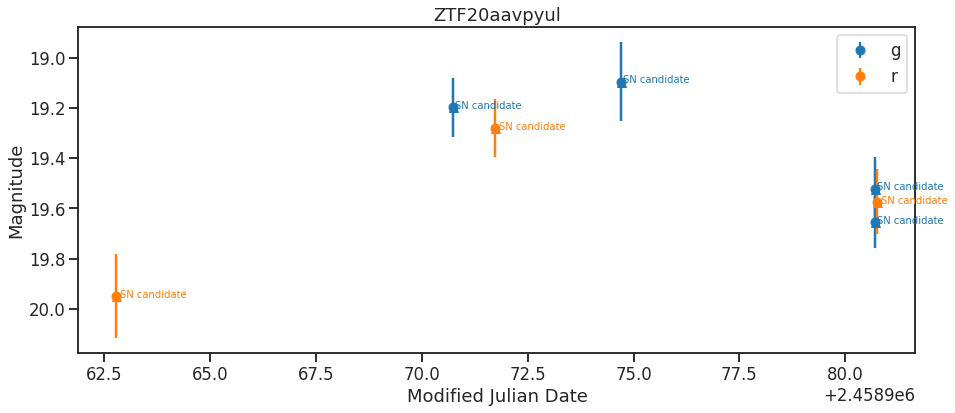

In [26]:
plot_lc(df_alerts, two_close_z_objId1['objectId'].iloc[0])

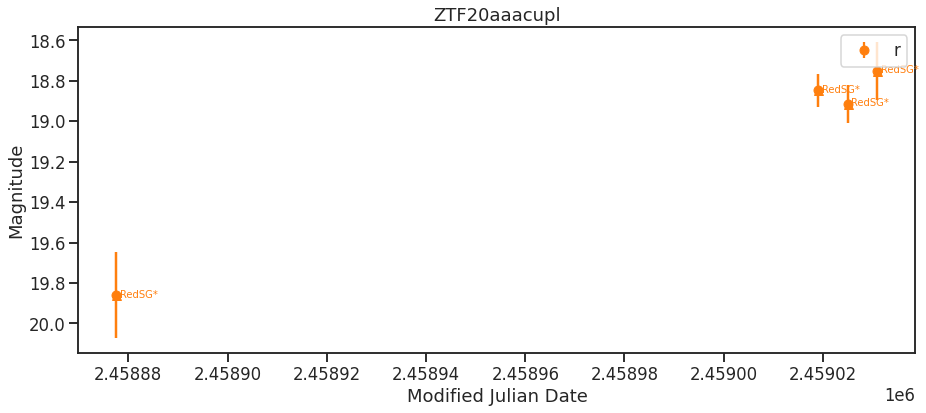

In [27]:
plot_lc(df_alerts, two_close_z_objId2['objectId'].iloc[0])

Example 3

In [36]:
two_close_z_indices = np.where(
    (outputs_condensed_condensed_transformed[:, 0] < -2) & (outputs_condensed_condensed_transformed[:, 0] > -3) &
    (outputs_condensed_condensed_transformed[:, 1] > -1.5) & (outputs_condensed_condensed_transformed[:, 1] < -1)
)[0]
two_close_z_objIds = objIds[two_close_z_indices]
two_close_z_objIds

array(['ZTF19aarguso', 'ZTF19aargtzk'], dtype='<U12')

In [37]:
two_close_z_objId1 = objIds_finkclass_all[objIds_finkclass_all['objectId'] == two_close_z_objIds[0]]
two_close_z_objId1

,objectId,finkclass
1678,ZTF19aarguso,Unknown


In [38]:
two_close_z_objId2 = objIds_finkclass_all[objIds_finkclass_all['objectId'] == two_close_z_objIds[1]]
two_close_z_objId2

,objectId,finkclass
438,ZTF19aargtzk,Candidate_LP*


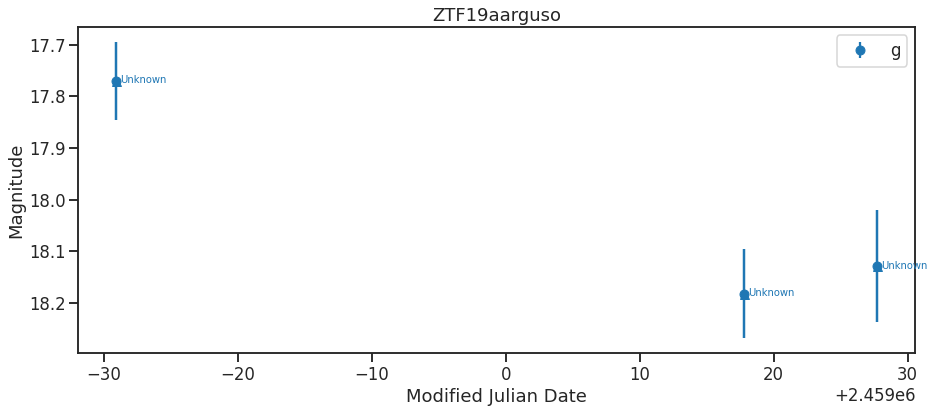

In [39]:
plot_lc(df_alerts, two_close_z_objId1['objectId'].iloc[0])

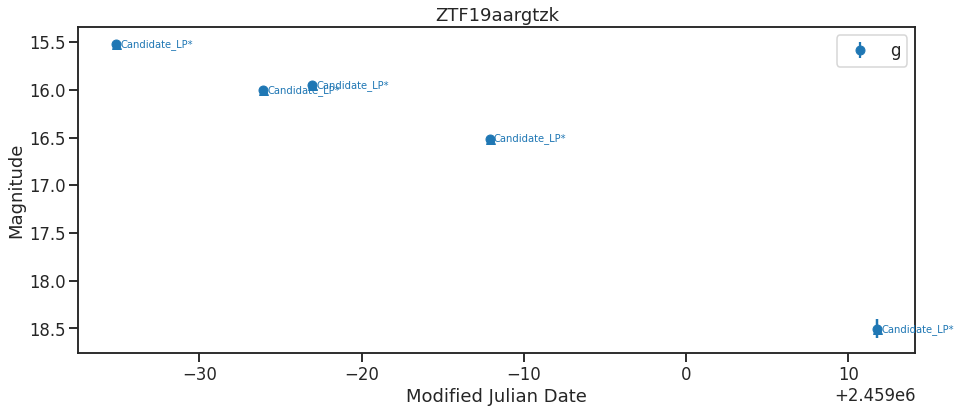

In [40]:
plot_lc(df_alerts, two_close_z_objId2['objectId'].iloc[0])

## No. of datapoints in light curves across the entire dataset

TODO: Make a detailed analysis of seq_len vs their finkclass (most-common-across-alerts). I previously saw only SN and SN-candidate to have seq_len > 30.

TODO: Is seq_len a good indicator of light curve duration? seq_len is total no. of datapoints including all bands. Perhaps we just need `max_length(pdf[filter1], pdf[filter2])`

In [18]:
def plot_lc(
        df_alerts, name, fid_column='fid', magpsf_column='magpsf', jd_column='jd',
        sigmapsf_column='sigmapsf', finkclass_column='finkclass', objectId_column='objectId'
):
    """Plots photometry for the given name (objectId) from the alerts dataframe.

    Parameters
    ----------
    name: str
        objectID
    """
    # Accumulate all alerts for the provided objectId
    pdf = df_alerts[df_alerts[objectId_column] == name].sort_values(by=jd_column)

    if pdf.empty:
        raise ValueError(f'No alerts exist for objectId = {name}!')

    fig = plt.figure(figsize=(15, 6))

    # Colors to plot
    colordic = {1: 'C0', 2: 'C1'}

    # Labels of ZTF filters
    filtdic = {1: 'g', 2: 'r'}

    for filt in np.unique(pdf[fid_column]):
        # select data from one filter at a time
        maskFilt = pdf[fid_column] == filt

        plt.errorbar(
            pdf[maskFilt][jd_column],
            pdf[maskFilt][magpsf_column],
            pdf[maskFilt][sigmapsf_column],
            ls = '', marker='o', color=colordic[filt], label=filtdic[filt]
        )

        plt.errorbar(
            pdf[maskFilt][jd_column],
            pdf[maskFilt][magpsf_column],
            pdf[maskFilt][sigmapsf_column],
            ls='', marker='^', color=colordic[filt]
        )

        if finkclass_column is not None:
            _offset_x = (pdf[maskFilt][jd_column].max() - pdf[maskFilt][jd_column].min()) / 200
            _offset_y = (pdf[maskFilt][magpsf_column].max() - pdf[maskFilt][magpsf_column].min()) / 100
            for x, y, string in zip(pdf[maskFilt][jd_column], pdf[maskFilt][magpsf_column], pdf[maskFilt][finkclass_column]):
                plt.text(
                    x+_offset_x, y+_offset_y, string,
                    color=colordic[filt]
                )

    plt.gca().invert_yaxis()
    plt.legend()
    plt.title(f'{pdf[objectId_column].unique()[0]}')
    plt.xlabel('Modified Julian Date')
    plt.ylabel('Magnitude')
    plt.show()
    # msg = """
    # - Circles (●) with error bars show valid alerts that pass the Fink quality cuts.
    # - Upper triangles with errors (▲), represent alert measurements that do not satisfy Fink quality cuts, but are nevetheless contained in the history of valid alerts and used by classifiers.
    # - Lower triangles (▽), represent 5-sigma mag limit in difference image based on PSF-fit photometry contained in the history of valid alerts.
    # """
    # print(msg)

def get_lc(
        df_alerts, name, fid_column='fid', magpsf_column='magpsf', jd_column='jd',
        objectId_column='objectId', sigmapsf_column='sigmapsf', finkclass_column='finkclass',
        #extract_subset=False, start_index=None, end_index=None
        make_first_time_zero=True, convert_to_tensor=False
    ):
    """Get the light curve given an alerts dataframe (df_alerts) and the objectId (name).
    
    Returns a tuple (object_Id, tt, vals, mask, labels)
    """
    # Accumulate all alerts for the provided objectId
    pdf = df_alerts[df_alerts[objectId_column] == name].sort_values(by=jd_column)

    if pdf.empty:
        raise ValueError(f'No alerts exist for objectId = {name}, so cannot make a light curve!')

    # Labels of ZTF filters
    filtdic = {1: 'g', 2: 'r'}

    observation_data, observation_mask = [], []
    # for filt in np.unique(pdf['fid']):
    # Don't loop over pdf['fid'] since in pdf, we might not get all filters. For creating the dataset, we need fixed-sized arrays, so we should select all filters instead of filters seen in this pdf.
    for filt in np.unique(df_alerts[fid_column]):
        #if extract_subset:
        #    maskFilt = pdf[fid_column] == filt
        #    observation_data.append(
        #        (pdf[magpsf_column] * maskFilt).iloc[start_index:end_index]
        #    )
        #    observation_mask.append(
        #        maskFilt.astype(int)
        #    )
        #else:
        maskFilt = pdf[fid_column] == filt
        observation_data.append(
            pdf[magpsf_column] * maskFilt  # because when observation for this filter is not present, we want to replace the observed value with zero, as done in the mTAN code.
        )
        observation_mask.append(
            maskFilt.astype(int)
        )

    observation_data = np.array(observation_data).T  # after transpose: seqlen x num_channels
    observation_mask = np.array(observation_mask).T  # after transpose: seqlen x num_channels

    times = np.expand_dims(pdf[jd_column], 1)  # Add dimension at the 1st index to prepare for concatenation.
    #data = np.concatenate((observation_data, observation_mask, times), axis=1)

    if make_first_time_zero:
        # Make the first time to zero. The below two lines are only for machine learning purposes since the time must always start at zero for all light curves.
        times = times - times[0]
        times = times * 24  # to convert times into hours.

    if finkclass_column is not None:  # finkclass_column will be None when getting the light curve from the API service instead of polling the alerts.
        common_finkclasses = df_alerts[df_alerts[objectId_column] == name][finkclass_column].mode().tolist()
    else:
        common_finkclasses = [None]

    if convert_to_tensor:
        times = torch.from_numpy(times)
        observation_data = torch.from_numpy(observation_data)
        observation_mask = torch.from_numpy(observation_mask)

    data = (name, times, observation_data, observation_mask, common_finkclasses)

    return data

7.981289366432012 6.0


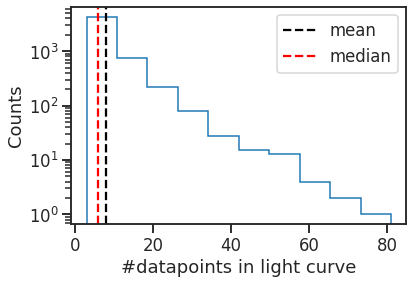

In [19]:
import numpy as np
import pandas as pd

df_alerts = pd.read_parquet('alerts_processed_ftransfer_ztf_2024_04_02_252737.parquet')

num_data_points_all = []

for objId in df_alerts['objectId'].unique():
    data = get_lc(df_alerts, objId, make_first_time_zero=False, convert_to_tensor=False)
    # data = (name, times, observation_data, observation_mask, common_finkclasses)
    num_data_points_all.append(len(data[1]))

import matplotlib.pyplot as plt
plt.hist(num_data_points_all, histtype='step')
plt.yscale('log')
plt.xlabel('#datapoints in light curve')
plt.ylabel('Counts')
plt.axvline(x=np.mean(num_data_points_all), linestyle='--', c='black', label='mean')
plt.axvline(x=np.median(num_data_points_all), linestyle='--', c='red', label='median')
plt.legend()
# plt.savefig('num_datapoints_all.png', bbox_inches='tight')

print(np.mean(num_data_points_all), np.median(num_data_points_all))

## Projection (PCA/UMAP/t-SNE) colored with min mags of lcs

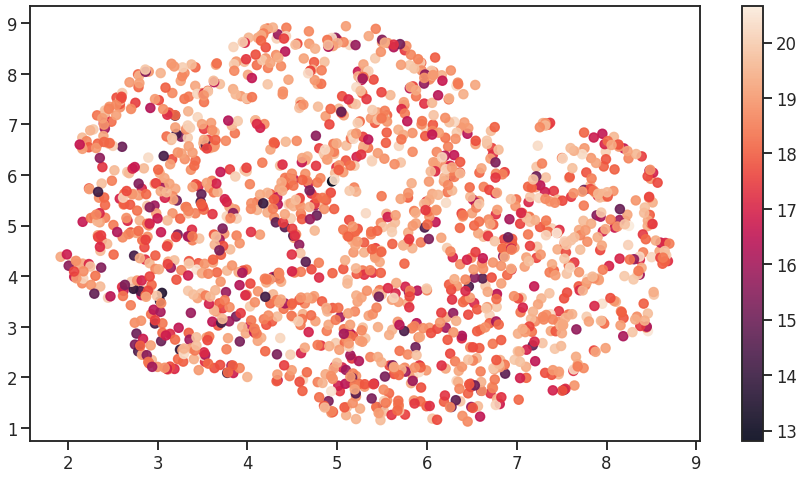

In [20]:
min_mags = []
for i, oi in enumerate(test_objIds):
    data = get_lc(df_alerts, oi)
    obs = data[2]
    min_mags.append(obs[obs != 0.0].min())

fig, ax = plt.subplots(1, 1, figsize=(15, 8))
sc = ax.scatter(
    test_outputs_condensed_condensed_transformed[:, 0], test_outputs_condensed_condensed_transformed[:, 1],
    c=min_mags, alpha=0.9
)
plt.colorbar(sc)

## Show random light curves

Main point of analysis is to see qualitatively how many light curves are uninteresting (flat with mostly noise).

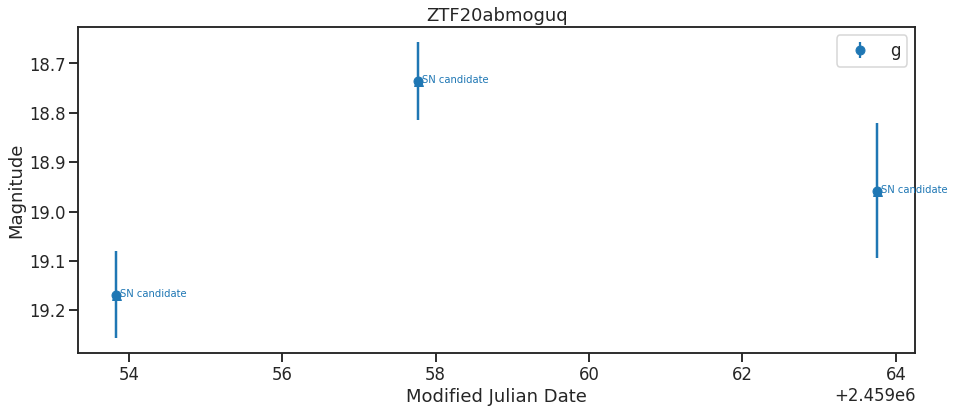

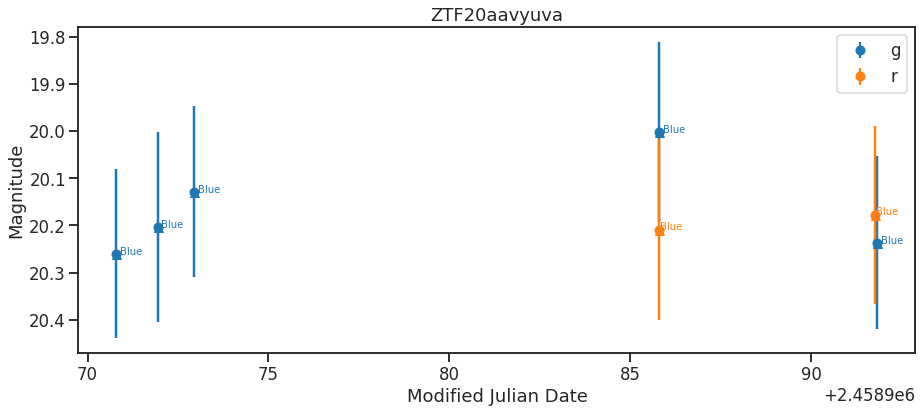

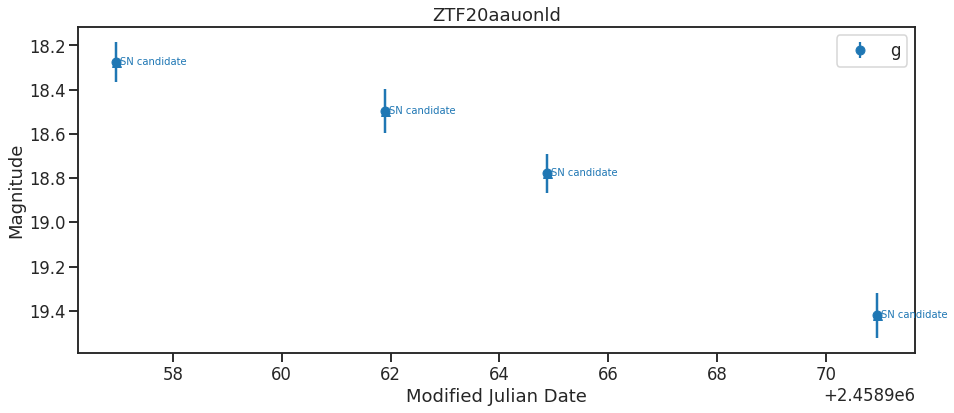

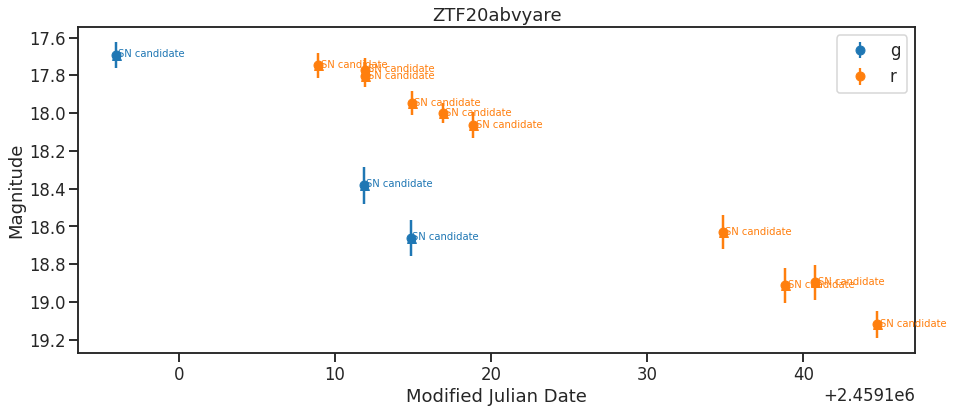

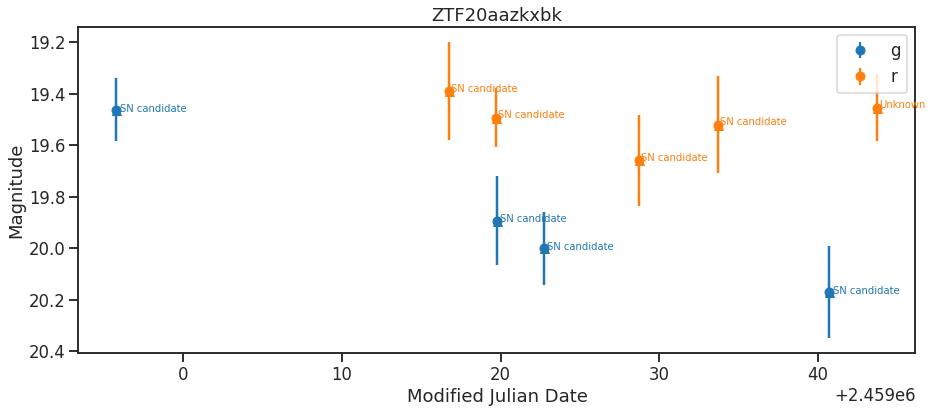

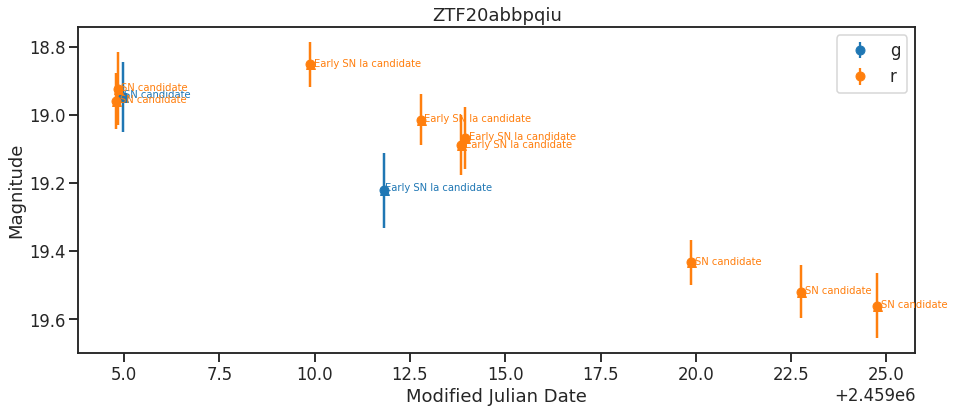

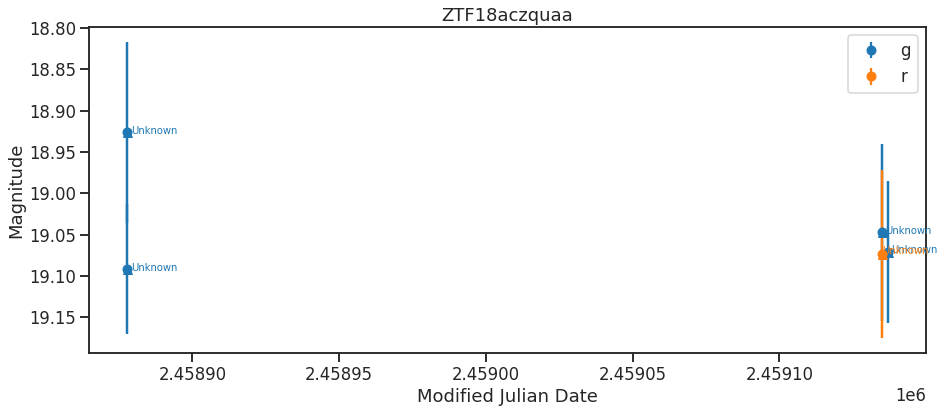

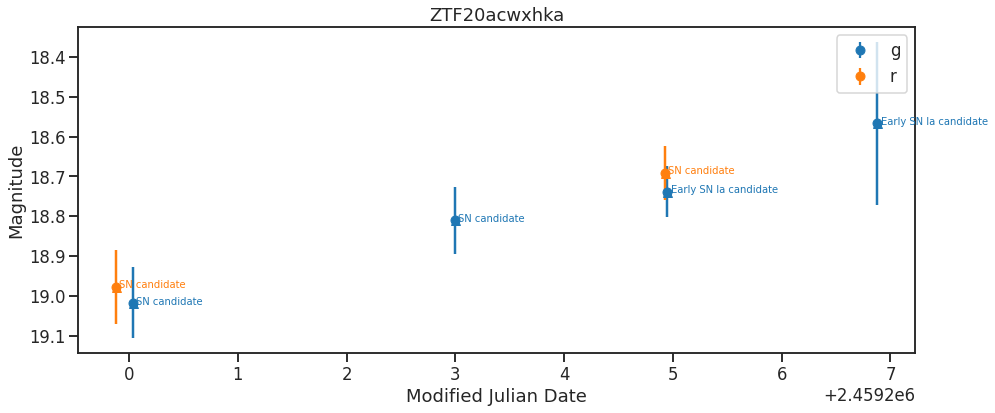

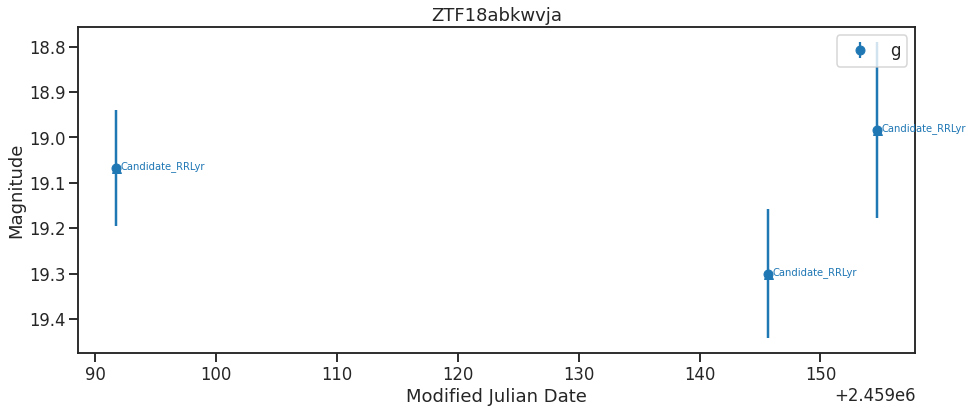

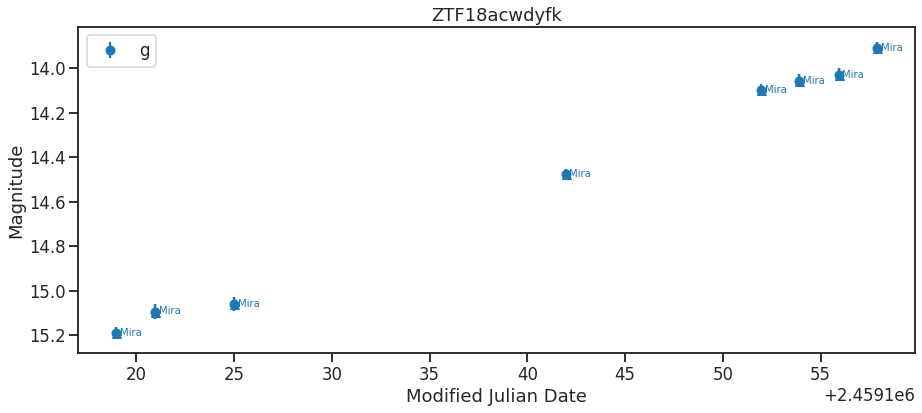

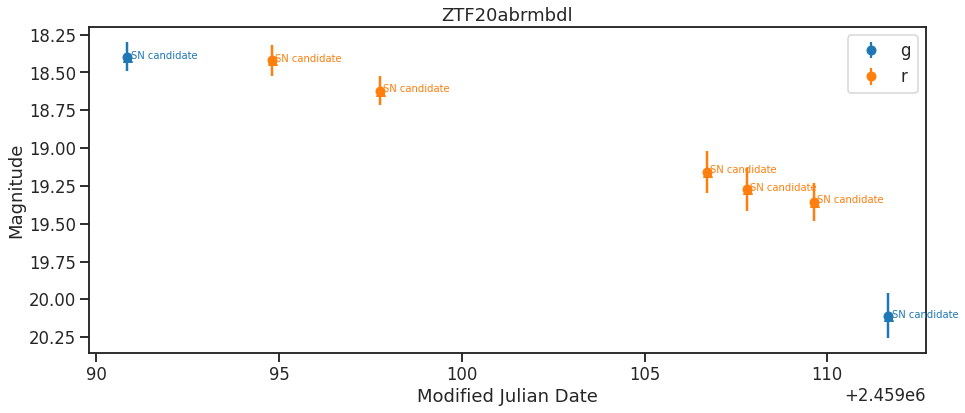

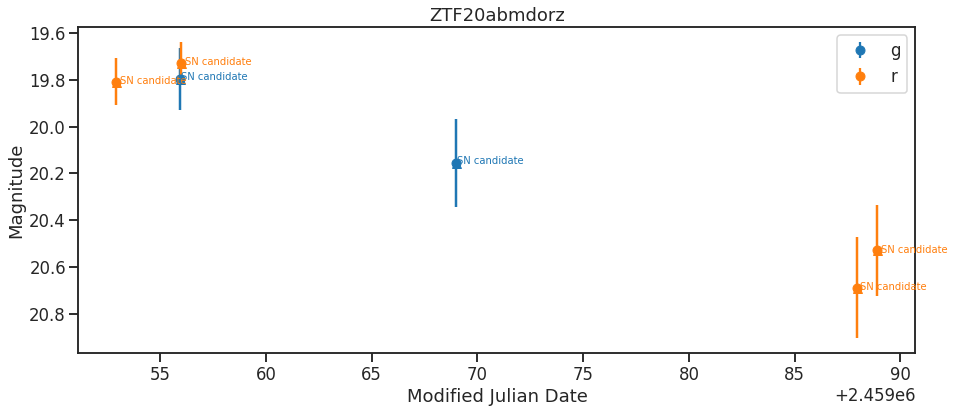

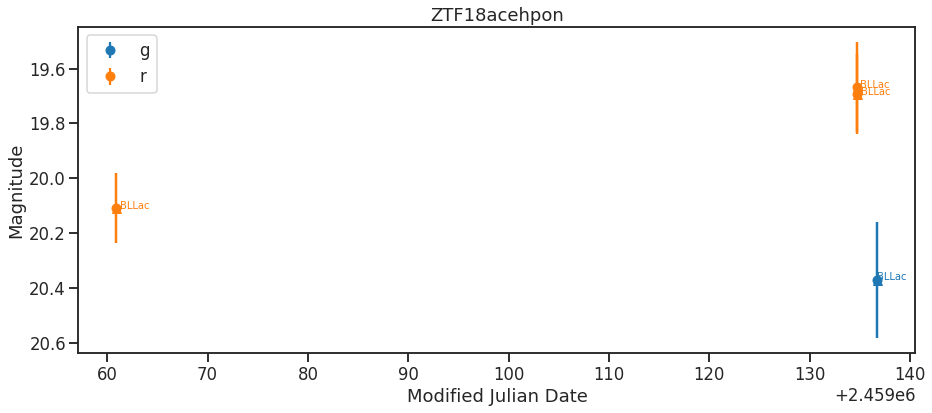

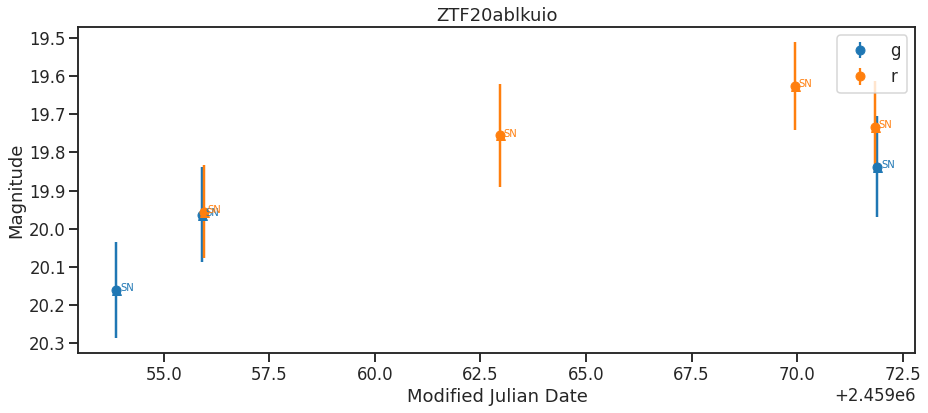

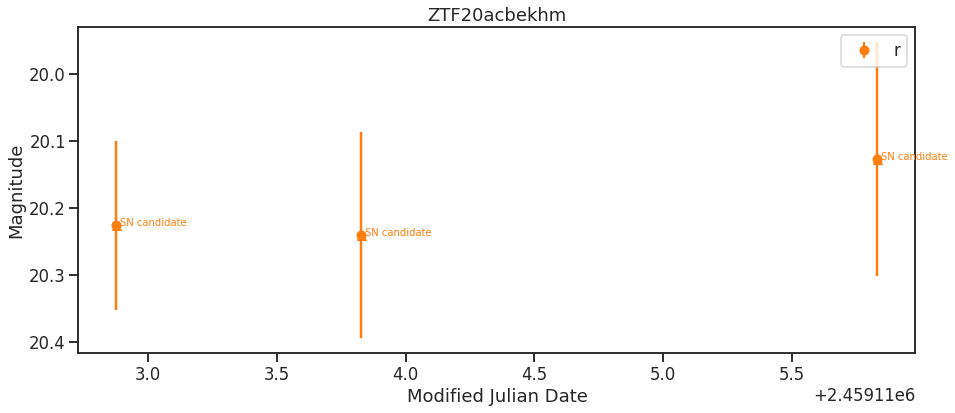

In [21]:
np.random.seed(42)
random_objIds = np.random.choice(df_alerts['objectId'].unique(), size=15, replace=False)

for oi in random_objIds:
    plot_lc(df_alerts, oi)

## Show the values of times

In [22]:
def normalize_times(times):
    normalized_times = (times - np.min(times)) / (np.max(times) - np.min(times))
    normalized_times *= 48
    return normalized_times

for i, objId in enumerate(df_alerts['objectId'].unique()):
    data = get_lc(df_alerts, objId, make_first_time_zero=True, convert_to_tensor=False)
    # data = (name, times, observation_data, observation_mask, common_finkclasses)
    # print(normalize_times(data[1]))
    print(data[1])
    if i == 10:
        break

[[   0.        ]
 [ 621.97416719]
 [ 668.9758344 ]
 [ 765.5544432 ]
 [ 812.8569432 ]
 [ 813.476388  ]
 [ 957.5508336 ]
 [ 981.4063896 ]
 [1292.7444432 ]
 [1293.65277839]
 [1340.510556  ]
 [1363.4972232 ]
 [1365.0838896 ]
 [1388.4825    ]
 [1411.4744448 ]
 [1459.3075008 ]
 [1603.6119432 ]
 [1700.1794448 ]
 [1747.0024992 ]]
[[   0.        ]
 [ 599.5136112 ]
 [ 645.5127768 ]
 [ 718.8197208 ]
 [ 767.0441664 ]
 [ 768.0316656 ]
 [1078.06333199]
 [1291.99194479]
 [1292.91138719]
 [1364.9524992 ]
 [1366.0305552 ]
 [1390.77111119]
 [1413.4602768 ]
 [1413.538332  ]
 [1604.531388  ]
 [1866.54333359]
 [2011.5219432 ]
 [2012.1872208 ]
 [2228.46999839]]
[[  0.        ]
 [ 95.4216648 ]
 [359.00111039]
 [359.6041656 ]
 [597.4972224 ]
 [597.5199984 ]
 [599.488332  ]
 [718.47249839]
 [863.1555552 ]
 [934.43416559]]
[[  0.        ]
 [ 49.60638961]
 [118.5630552 ]
 [385.71583441]
 [407.6947224 ]]
[[   0.        ]
 [ 887.67305521]
 [6270.9897216 ]
 [6318.9822216 ]
 [6319.05027841]
 [6629.57500081]
 [6677.5

In [23]:
for i, objId in enumerate(df_alerts['objectId'].unique()):
    data = get_lc(df_alerts, objId, make_first_time_zero=True, convert_to_tensor=False)
    # data = (name, times, observation_data, observation_mask, common_finkclasses)
    print(normalize_times(data[1]))
    if i == 10:
        break

[[ 0.        ]
 [17.08913412]
 [18.3805347 ]
 [21.03409313]
 [22.33375928]
 [22.35077892]
 [26.30931555]
 [26.96476206]
 [35.51897224]
 [35.54392933]
 [36.83137644]
 [37.46294968]
 [37.50654434]
 [38.14943598]
 [38.78115422]
 [40.09539773]
 [44.06025367]
 [46.71350693]
 [48.        ]]
[[ 0.        ]
 [12.91318858]
 [13.90398494]
 [15.48297559]
 [16.52170324]
 [16.54297342]
 [23.22088248]
 [27.8287854 ]
 [27.84858967]
 [29.40031502]
 [29.42353574]
 [29.95643351]
 [30.44514547]
 [30.44682674]
 [34.56071057]
 [40.20430164]
 [43.32705998]
 [43.34138968]
 [48.        ]]
[[ 0.        ]
 [ 4.90161863]
 [18.44116358]
 [18.47214131]
 [30.69222823]
 [30.69339819]
 [30.79450752]
 [36.90648437]
 [44.33856143]
 [48.        ]]
[[ 0.        ]
 [ 5.84041581]
 [13.95903929]
 [45.41231229]
 [48.        ]]
[[ 0.        ]
 [ 5.78014738]
 [40.8340037 ]
 [41.14651034]
 [41.1469535 ]
 [43.16895772]
 [43.48104833]
 [43.4849824 ]
 [43.79358391]
 [44.10287274]
 [45.04051386]
 [45.35724217]
 [45.50958039]
 [47.3